# **Part FOUR: Pandas Operations**

* Manipulating Data with applymap() for Element-Wise Operations
* Using Conditional Logic to Modify Data
* Stacking and Unstacking Data

## **Manipulating Data with applymap() for Element-Wise Operations**

**What is applymap()?**
* applymap() is a Pandas function that lets you apply a function to every single element in a DataFrame.
* It is used for element-wise transformations, meaning it works on each individual cell of the DataFrame.

**How applymap() Works**
* You define a function (or use a built-in one).
* applymap() applies that function to every element in the DataFrame, one cell at a time.

Example 1: Converting Values to Strings

Imagine you have a dataset of product sales, and you want to convert all numerical data to strings.

In [ ]:
import pandas as pd

# Create the DataFrame
data = pd.DataFrame({
    'Product': ['Laptop', 'Mouse', 'Keyboard'],
    'Price': [1000, 50, 70],
    'Stock': [25, 150, 50]
})

print("\n", data)
print("\n",data.dtypes)

# Apply applymap to convert all elements to strings

string_data = data.applymap(str)

#map function
#str_data = data['Price'].map(str)

print("\n","DataFrame with all values as strings:")
print("\n",string_data)
print(string_data.dtypes)
print("\n",string_data.dtypes)


     Product  Price  Stock
0    Laptop   1000     25
1     Mouse     50    150
2  Keyboard     70     50

 Product    object
Price       int64
Stock       int64
dtype: object

 DataFrame with all values as strings:

     Product Price Stock
0    Laptop  1000    25
1     Mouse    50   150
2  Keyboard    70    50
Product    object
Price      object
Stock      object
dtype: object

 Product    object
Price      object
Stock      object
dtype: object


/tmp/ipykernel_834/1880991727.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  string_data = data.applymap(str)


Example 2: Adding a Dollar Sign to Prices

Let’s say you want to format all numeric values by adding a dollar sign.

In [ ]:
# $ sign addition to Price

import pandas as pd

# Create the DataFrame
data = pd.DataFrame({
    'Product': ['Laptop', 'Mouse', 'Keyboard'],
    'Price': [1000, 50, 70],
    'Stock': [25, 150, 50]
})

# Apply a lambda function on the 'Price' column to add a dollar sign

data[['Price']] = data[['Price']].applymap(lambda x: "$" + str(x))

print(data)

    Product  Price  Stock
0    Laptop  $1000     25
1     Mouse    $50    150
2  Keyboard    $70     50


/tmp/ipykernel_834/644966853.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data[['Price']] = data[['Price']].applymap(lambda x: "$" + str(x))


In [ ]:
# Use Map() Method
import pandas as pd

# Create the DataFrame
data = pd.DataFrame({
    'Product': ['Laptop', 'Mouse', 'Keyboard'],
    'Price': [1000, 50, 70],
    'Stock': [25, 150, 50]
})

# Add a dollar sign to the Price column
data['Price'] = data['Price'].map(lambda x: f"${x}")

print(data)
print("\nData Types:")
print(data.dtypes)

    Product  Price  Stock
0    Laptop  $1000     25
1     Mouse    $50    150
2  Keyboard    $70     50

Data Types:
Product    object
Price      object
Stock       int64
dtype: object


In [ ]:
# Use Apply Method
import pandas as pd

data = pd.DataFrame({
    'Product': ['Laptop', 'Mouse', 'Keyboard'],
    'Price': [1000, 50, 70],
    'Stock': [25, 150, 50]
})

data['Price'] = data['Price'].apply(lambda x: "$" + str(x))

print(data)

    Product  Price  Stock
0    Laptop  $1000     25
1     Mouse    $50    150
2  Keyboard    $70     50


 **When to Use applymap()**

1.Element-Wise Transformations:

* When you need to apply a function to every cell in the DataFrame.
* Example: Formatting, converting, or applying calculations to each element.

2.Data Cleaning or Formatting:

* Example: Converting all numeric values to strings, formatting text, or applying conditional changes.
3.Custom Operations:

* When no built-in Pandas method exists for the task, and you need a custom function.

**When NOT to Use applymap()**

1.For Large Datasets:

* applymap() can be slow for very large DataFrames because it processes each element individually.

2.When Built-In Vectorized Functions Exist:

* If Pandas provides a built-in function (e.g., df['column'].astype(str)), it’s faster and more efficient to use that instead of applymap().

## **Using Conditional Logic to Modify Data**

**What is it?**

Using conditional logic to modify data means changing the values in a DataFrame based on certain conditions. It's like setting rules for how specific rows or columns should be updated.

For example:

* If the stock level is below 50, mark it as "Low Stock."
* If the price is greater than $500, apply a discount.

**Example 1: Labeling Stock Levels**

You have a dataset of products and their stock levels. You want to add a column to label stock levels as:

* "Low Stock" if the stock is below 50.
* "Normal Stock" if the stock is between 50 and 100.
* "High Stock" if the stock is above 100.


In [ ]:
import pandas as pd

# Create the DataFrame
data = pd.DataFrame({
    'Product': ['Laptop', 'Mouse', 'Keyboard'],
    'Stock': [25, 150, 50],
    'Price': [1000, 50, 70]
})

print("\n",data)
# Add a new column using conditional logic

data['Stock Level'] = data['Stock'].apply(
    lambda x: 'Low Stock' if x < 50 else 'Normal Stock' if x <= 100 else 'High Stock'
)

print("\n","DataFrame with Stock Level column:")
print("\n",data)


     Product  Stock  Price
0    Laptop     25   1000
1     Mouse    150     50
2  Keyboard     50     70

 DataFrame with Stock Level column:

     Product  Stock  Price   Stock Level
0    Laptop     25   1000     Low Stock
1     Mouse    150     50    High Stock
2  Keyboard     50     70  Normal Stock


**Example 2: Applying a Discount**

You want to apply a 10% discount to products priced above $500.

In [7]:
import pandas as pd

# Create the DataFrame
data = pd.DataFrame({
    'Product': ['Laptop', 'Mouse', 'Keyboard'],
    'Stock': [25, 150, 50],
    'Price': [1000, 50, 70]
})

# Add a new column using conditional logic
data['Stock Level'] = data['Stock'].apply(
    lambda x: 'Low Stock' if x < 50 else 'Normal Stock' if x <= 100 else 'High Stock'
)

# apply discounted price
data['Discounted Price'] = data['Price'].apply(
    lambda x: x * 0.9 if x > 500 else x
)

print("DataFrame with Discounted Price column:")
print(data)

DataFrame with Discounted Price column:
    Product  Stock  Price   Stock Level  Discounted Price
0    Laptop     25   1000     Low Stock             900.0
1     Mouse    150     50    High Stock              50.0
2  Keyboard     50     70  Normal Stock              70.0


**Example 3: Categorizing Products**

You want to categorize products based on price:

* "Expensive" if the price is above $500.
* "Affordable" otherwise.

In [8]:
# Add a category column based on price

data['Category'] = data['Price'].apply(
    lambda x : 'Expensive' if x > 500 else 'Affordable'
)

print('DataFrame with Category column:')
print('\n',data)

DataFrame with Category column:

     Product  Stock  Price   Stock Level  Discounted Price    Category
0    Laptop     25   1000     Low Stock             900.0   Expensive
1     Mouse    150     50    High Stock              50.0  Affordable
2  Keyboard     50     70  Normal Stock              70.0  Affordable


## **Stacking and Unstacking Data**

**What is Stacking?**
* Stacking means turning columns into rows.
* It rearranges data to make it long and narrow, which is often useful for deeper analysis or grouping.

**What is Unstacking?**
* Unstacking is the opposite of stacking—it turns rows into columns.
* It rearranges data to make it wide and short, which is helpful for comparisons or summaries.

**Why Use Stacking and Unstacking?**

They help in reshaping the data to make it suitable for specific analysis.

For example:
* Stacking makes it easier to work with grouped data.
* Unstacking makes it easier to compare values across groups.

Original Data:
Imagine you have sales data for two products (Laptop and Mouse) over two years (2020 and 2021).

In [9]:
import pandas as pd

# Create a DataFrame
data = pd.DataFrame({
    'City': ['New York', 'Los Angeles'],
    'Laptop Sales (2020)': [200, 150],
    'Laptop Sales (2021)': [250, 300],
    'Mouse Sales (2020)': [50, 70],
    'Mouse Sales (2021)': [60, 90]
})

print("Original DataFrame:")
data

Original DataFrame:


,City,Laptop Sales (2020),Laptop Sales (2021),Mouse Sales (2020),Mouse Sales (2021)
0,New York,200,250,50,60
1,Los Angeles,150,300,70,90


**Stacking Data**

Stacking moves columns into rows.



In [10]:
# Stack the columns into rows
stacked_data = data.set_index('City').stack()

print("\nStacked DataFrame:")
print("\n",stacked_data)


Stacked DataFrame:

 City                            
New York     Laptop Sales (2020)    200
             Laptop Sales (2021)    250
             Mouse Sales (2020)      50
             Mouse Sales (2021)      60
Los Angeles  Laptop Sales (2020)    150
             Laptop Sales (2021)    300
             Mouse Sales (2020)      70
             Mouse Sales (2021)      90
dtype: int64


**Unstacking Data**

Unstacking moves rows back into columns.

In [11]:
# Stack Data Convert Into Unstack(rows into columns.)
unstacked_data = stacked_data.unstack()
print('\nUnStacked DataFrame')
unstacked_data


UnStacked DataFrame


,Laptop Sales (2020),Laptop Sales (2021),Mouse Sales (2020),Mouse Sales (2021)
City,,,,
New York,200,250,50,60
Los Angeles,150,300,70,90


Summary Table: When to Use and When NOT to Use Stacking and Unstacking

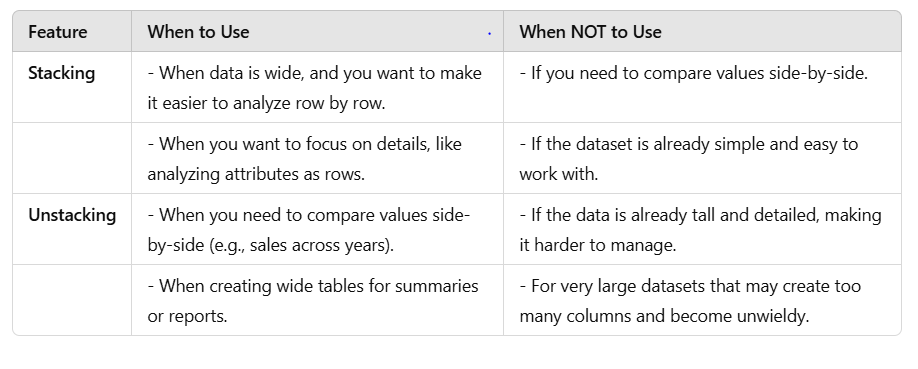

# **Part FIVE: Pandas User-Defined Functions**

* Pandas User-Defined Functions
* Using apply() and Lambda Functions in Pandas
* Formatting Numbers
* Applying Conditional Logic

**What is it?**
* A User-Defined Function (UDF) in Pandas is a custom function you write to perform specific operations on your data.
* You can use UDFs when built-in Pandas functions don’t meet your needs.
* Think of it like writing your own rule:

Example: Calculate a custom discount, format strings, or apply special logic.

**How to Use It**

1.Write the Function:
* Define your custom logic using Python’s def keyword.

2.Apply the Function:
* Use Pandas methods like .apply() or .applymap() to apply the function to rows, columns, or individual cells.

**Formatting Strings**

You want to convert product names to uppercase and add "!" at the end.

In [14]:
import pandas as pd

data = pd.DataFrame({
    'Product' : ['Laptop','Mouse','Keyboard'],
    'Price' : [120,50,80]
})
print('\nOriginal Data Frame')
print('\n',data)


Original Data Frame

     Product  Price
0    Laptop    120
1     Mouse     50
2  Keyboard     80


In [15]:
# Define a custom function for formatting strings
def format_product(name):
  return name.upper() + '!'

# Apply the function to the Product column
data['Formatted Product'] = data['Product'].apply(format_product)

print("DataFrame with Formatted Product Names:")
print(data)

DataFrame with Formatted Product Names:
    Product  Price Formatted Product
0    Laptop    120           LAPTOP!
1     Mouse     50            MOUSE!
2  Keyboard     80         KEYBOARD!


**Example: Categorizing Customers Based on Spending**

You have a dataset of customers and their total spending. You want to classify each customer into three categories based on their spending:

* Low Spender: Spending less than 100.
* Medium Spender: Spending between 100 and 500.
* High Spender: Spending more than 500.

In [17]:
import pandas as pd

data = pd.DataFrame({
  'Customer': ['John', 'Sarah', 'Mike', 'Emma', 'Dave'],
  'Total Spending': [50, 120, 700, 300, 90]
})

print('\n Original Data Frame')
print(data)


 Original Data Frame
  Customer  Total Spending
0     John              50
1    Sarah             120
2     Mike             700
3     Emma             300
4     Dave              90


In [18]:
# Define a custom function to categorize spending
def categorize_spending(spending):
    if spending < 100:
        return "Low Spender"
    elif 100 <= spending <= 500:
        return "Medium Spender"
    else:
        return "High Spender"

# Apply the function to the Total Spending column
data['Spending Category'] = data['Total Spending'].apply(categorize_spending)

print("\nDataFrame with Spending Categories:")
print(data)


DataFrame with Spending Categories:
  Customer  Total Spending Spending Category
0     John              50       Low Spender
1    Sarah             120    Medium Spender
2     Mike             700      High Spender
3     Emma             300    Medium Spender
4     Dave              90       Low Spender


**When to Use This Approach**

1.For Custom Classifications:

* When you need to classify data into specific categories based on rules.

2.For Clear Business Logic:

* Example: Classifying customers, products, or transactions into custom tiers.

**When NOT to Use This Approach**

For Large Datasets:If the dataset is very large, apply() can be slow since it processes rows one by one.

## **Using apply() and Lambda Functions in Pandas**

**What is apply() in Pandas?**
* apply() lets you apply a custom function (or logic) to rows or columns in your DataFrame.
* It’s useful when you want to apply a specific rule or transformation that isn’t already built into Pandas.

How to Use apply() with Lambda Functions

1.For Columns:

* Apply transformations to entire columns using .apply().

2.For Rows:

* Use .apply() with axis=1 to apply logic across rows.

**Cleaning Messy Data**

You have a column of names with inconsistent formatting (extra spaces, mixed cases). You want to:

* Remove extra spaces.
* Convert names to proper case (e.g., "john doe" → "John Doe").

In [21]:
import pandas as pd

# Create a Data Frame
data = pd.DataFrame({'Name': ['  john doe  ', 'SARAH SMITH', ' mike  ']})

print("Original DataFrame:")
print(data)

# Clean names using apply() with a lambda function
data['Clean Name'] = data['Name'].apply(
    lambda x : x.strip().title()
)

print("\nDataFrame with Cleaned Names:")
data

Original DataFrame:
           Name
0    john doe  
1   SARAH SMITH
2        mike  

DataFrame with Cleaned Names:


,Name,Clean Name
0,john doe,John Doe
1,SARAH SMITH,Sarah Smith
2,mike,Mike


What Happened?

* x.strip(): Removes extra spaces.
* x.title(): Converts names to proper case.


## **Formatting Numbers**

You have a column of prices, and you want to add a "$" sign to each price.

In [27]:
import pandas as pd

# Create a DataFrame
data = pd.DataFrame({'Price': [10, 20.5, 30]})

print("Original DataFrame:")
print(data)

# Format prices using apply() with a lambda function
data['Formatted Price'] = data['Price'].apply(lambda x: f"${x:.2f}")

print("\nDataFrame with Formatted Prices:")
print(data)

Original DataFrame:
   Price
0   10.0
1   20.5
2   30.0

DataFrame with Formatted Prices:
   Price Formatted Price
0   10.0          $10.00
1   20.5          $20.50
2   30.0          $30.00


What Happened?

f" $ {x:.2f}": Formats numbers with two decimal places and adds a dollar sign.

## **Applying Conditional Logic**

You have a column of scores and want to assign grades:

* Score > 80 → "A"
* Score between 50 and 80 → "B"
* Score < 50 → "C"

In [29]:
import pandas as pd

data = pd.DataFrame({'Score': [85, 70, 40]})

print("Original DataFrame:")
print(data)

# Assign grades using apply() with a lambda function

data['Grade'] = data['Score'].apply(
    lambda x: 'A' if x > 80 else 'B' if x >= 50 else 'C'
)

print("\nDataFrame with Grades:")
print(data)

Original DataFrame:
   Score
0     85
1     70
2     40

DataFrame with Grades:
   Score Grade
0     85     A
1     70     B
2     40     C


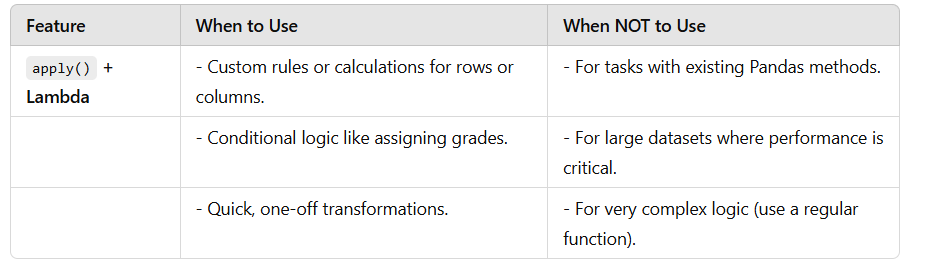